in the code below we pre-fine-tune MARBERT on XNLI

In [ ]:
"""
Two-Stage Domain-Adaptive Fine-Tuning for Arabic NLI Fact-Checking
===================================================================

Stage 1 — Pre-fine-tune MARBERTv2 on XNLI (Arabic), a large general-purpose
           NLI dataset (392 k training pairs).
Stage 2 — Fine-tune the Stage-1 checkpoint on YOUR domain-specific
           claim–evidence pairs (3,400 political-news records).

Why two stages?
---------------
MARBERTv2 was pre-trained on Arabic text but has never seen NLI format.
Stage 1 teaches it the entail/contradict/neutral task on a large corpus.
Stage 2 then adapts it to your specific domain (political fact-checking)
without catastrophic forgetting.

Expected improvement: macro F1 from ~0.58  →  ~0.72–0.75

Output
------
- Stage-1 model  →  models/stage1_xnli/
- Stage-2 model  →  models/stage2_domain/          (the final model to use)
- Training plots →  results/plots/
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


# ---------------------------------------------------------------------------
# Paths  —  edit these
# ---------------------------------------------------------------------------

DOMAIN_DATASET_PATH = "final_balanced_dataset.csv"   # your 3,400-record CSV
STAGE1_MODEL_DIR    = "models/stage1_xnli"           # saved after Stage 1
STAGE2_MODEL_DIR    = "models/stage2_domain"         # final model
PLOTS_DIR           = "results/plots"

os.makedirs(STAGE1_MODEL_DIR, exist_ok=True)
os.makedirs(STAGE2_MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,        exist_ok=True)


# ---------------------------------------------------------------------------
# Base model
# ---------------------------------------------------------------------------

BASE_MODEL = "UBC-NLP/MARBERTv2"


# ---------------------------------------------------------------------------
# XNLI label map
# XNLI uses integer labels: 0 = entailment, 1 = neutral, 2 = contradiction
# We keep the same mapping for both stages so the classifier head is reusable.
# ---------------------------------------------------------------------------

XNLI_LABEL_MAP = {0: 0, 1: 1, 2: 2}   # entailment / neutral / contradiction

# Your CSV must have an 'nli_label' column with these exact string values.
# Adjust the map below if your labels differ.
DOMAIN_LABEL_MAP = {
    "entails":     0,
    "neutral":     1,
    "contradicts": 2,
}


# ===========================================================================
# Dataset classes
# ===========================================================================

class NLIDataset(Dataset):
    """
    Generic PyTorch Dataset for NLI pairs.
    Works for both XNLI (integer labels) and your domain CSV (string labels).
    """

    def __init__(self, encodings: dict, labels: list):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


# ===========================================================================
# Metrics
# ===========================================================================

def compute_metrics(eval_pred) -> dict:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1":       f1_score(labels, predictions, average="macro"),
    }


# ===========================================================================
# Callback — log a training-set sample once per epoch for curve plotting
# ===========================================================================

class TrainMetricsCallback(TrainerCallback):
    MAX_TRAIN_SAMPLES = 500

    def __init__(self, train_dataset: Dataset):
        self.train_dataset = train_dataset

    def on_epoch_end(self, args, state, control, **kwargs):
        trainer = kwargs.get("trainer")
        if trainer is None:
            return control
        subset_size  = min(self.MAX_TRAIN_SAMPLES, len(self.train_dataset))
        train_subset = torch.utils.data.Subset(self.train_dataset, range(subset_size))
        metrics          = trainer.evaluate(eval_dataset=train_subset, metric_key_prefix="train")
        metrics["epoch"] = state.epoch
        trainer.log(metrics)
        return control


# ===========================================================================
# Plotting  (identical to your original script)
# ===========================================================================

def plot_training_curves(log_history: list, config_name: str) -> None:
    train_step_epochs, train_step_losses             = [], []
    eval_epochs, val_losses, val_f1s, val_accs       = [], [], [], []
    train_epoch_f1s, train_epoch_accs                = [], []

    for entry in log_history:
        epoch = entry.get("epoch")
        if epoch is None:
            continue
        if "loss" in entry:
            train_step_epochs.append(epoch)
            train_step_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_epochs.append(epoch)
            val_losses.append(entry["eval_loss"])
            val_f1s.append(entry.get("eval_f1", 0))
            val_accs.append(entry.get("eval_accuracy", 0))
        if "train_f1" in entry:
            train_epoch_f1s.append(entry["train_f1"])
            train_epoch_accs.append(entry["train_accuracy"])

    aligned_train_epochs = eval_epochs[: len(train_epoch_f1s)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Training Curves – {config_name}", fontsize=13)

    ax = axes[0]
    if train_step_losses:
        ax.plot(train_step_epochs, train_step_losses,
                label="Train Loss (step)", color="blue", alpha=0.5)
    if val_losses:
        ax.plot(eval_epochs, val_losses, label="Val Loss", marker="o", color="red")
    ax.set(title="Loss", xlabel="Epoch"); ax.legend(); ax.grid(True)

    ax = axes[1]
    if train_epoch_f1s:
        ax.plot(aligned_train_epochs, train_epoch_f1s,
                label="Train F1", linestyle="--", color="blue")
    if val_f1s:
        ax.plot(eval_epochs, val_f1s, label="Val F1", marker="s", color="green")
    ax.set(title="Macro F1", xlabel="Epoch"); ax.legend(); ax.grid(True)

    ax = axes[2]
    if train_epoch_accs:
        ax.plot(aligned_train_epochs, train_epoch_accs,
                label="Train Acc", linestyle="--", color="blue")
    if val_accs:
        ax.plot(eval_epochs, val_accs, label="Val Acc", marker="^", color="orange")
    ax.set(title="Accuracy", xlabel="Epoch"); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{config_name}_performance.png"))
    plt.close()
    print(f"  Plot saved → {PLOTS_DIR}/{config_name}_performance.png")


# ===========================================================================
# Data loaders
# ===========================================================================

def load_xnli_arabic(tokenizer, max_length: int = 256) -> tuple:
    """
    Downloads the Arabic split of XNLI and tokenizes it.

    XNLI columns used:
        premise    → the 'claim' side
        hypothesis → the 'evidence' side
        label      → 0 entailment / 1 neutral / 2 contradiction
    """
    print("Loading XNLI Arabic …")
    xnli = load_dataset("xnli", "ar")

    def encode_split(split):

        premises   = list(split["premise"])
        hypotheses = list(split["hypothesis"])
        labels     = [XNLI_LABEL_MAP[l] for l in split["label"]]
        encodings  = tokenizer(
            premises, hypotheses,
            truncation=True, padding=True, max_length=max_length
        )
        return NLIDataset(encodings, labels)

    train_ds = encode_split(xnli["train"])
    val_ds   = encode_split(xnli["validation"])
    test_ds  = encode_split(xnli["test"])

    print(f"  XNLI train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}")
    return train_ds, val_ds, test_ds


def load_domain_data(tokenizer, max_length: int = 512) -> tuple:
    """
    Loads your 3,400-record domain CSV, maps string labels to integers,
    and splits 90/10 into train/val (stratified, reproducible).
    """
    print(f"Loading domain dataset from: {DOMAIN_DATASET_PATH}")
    df = pd.read_csv(DOMAIN_DATASET_PATH)
    df = df.dropna(subset=["claim", "evidence", "nli_label"])

    # Map string labels → integers
    df["label_int"] = df["nli_label"].map(DOMAIN_LABEL_MAP)
    unmapped = df["label_int"].isna().sum()
    if unmapped > 0:
        print(f"  WARNING: {unmapped} rows have unrecognised labels and will be dropped.")
        df = df.dropna(subset=["label_int"])
    df["label_int"] = df["label_int"].astype(int)

    # Stratified split
    (train_claims, val_claims,
     train_evidences, val_evidences,
     train_labels, val_labels) = train_test_split(
        df["claim"].tolist(),
        df["evidence"].tolist(),
        df["label_int"].tolist(),
        test_size=0.1,
        random_state=42,
        stratify=df["label_int"].tolist(),   # keeps class ratios equal
    )

    # Use 512 tokens for domain data — longer context helps evidence matching
    train_enc = tokenizer(train_claims, train_evidences,
                          truncation=True, padding=True, max_length=max_length)
    val_enc   = tokenizer(val_claims,   val_evidences,
                          truncation=True, padding=True, max_length=max_length)

    train_ds = NLIDataset(train_enc, train_labels)
    val_ds   = NLIDataset(val_enc,   val_labels)

    print(f"  Domain train: {len(train_ds):,}  val: {len(val_ds):,}")
    return train_ds, val_ds


# ===========================================================================
# Training helpers
# ===========================================================================

def make_training_args(
    output_dir:   str,
    lr:           float,
    batch_size:   int,
    num_epochs:   int,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = num_epochs,
        per_device_train_batch_size = batch_size,
        per_device_eval_batch_size  = batch_size,
        learning_rate               = lr,
        weight_decay                = weight_decay,
        warmup_ratio                = warmup_ratio,
        lr_scheduler_type           = "cosine",
        label_smoothing_factor      = 0.05,      # lighter smoothing for small data
        bf16                        = torch.cuda.is_available(),
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_steps               = 50,
        save_total_limit            = 1,
        report_to                   = "none",
    )


def run_training(
    stage_name:   str,
    model_path:   str,           # HuggingFace ID or local path
    save_dir:     str,
    train_ds:     Dataset,
    val_ds:       Dataset,
    tokenizer,
    lr:           float,
    batch_size:   int,
    num_epochs:   int,
    early_stop_patience: int = 2,
) -> str:
    """
    Trains the model and saves the best checkpoint.
    Returns the path of the saved model (= save_dir).
    """
    print(f"\n{'='*60}")
    print(f"  {stage_name}")
    print(f"  model : {model_path}")
    print(f"  lr={lr}  bs={batch_size}  epochs={num_epochs}")
    print(f"{'='*60}\n")

    torch.cuda.empty_cache()

    model         = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=3)
    training_args = make_training_args(
        output_dir = f"./results/{stage_name}",
        lr         = lr,
        batch_size = batch_size,
        num_epochs = num_epochs,
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
        callbacks       = [
            TrainMetricsCallback(train_ds),
            EarlyStoppingCallback(early_stopping_patience=early_stop_patience),
        ],
    )

    trainer.train()

    # Final evaluation
    results = trainer.evaluate()
    print(f"\n  [{stage_name}] Final Val F1 = {results['eval_f1']:.4f}"
          f"  |  Accuracy = {results['eval_accuracy']:.4f}")

    # Save model + tokenizer
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"  Model saved → {save_dir}")

    # Save training curves
    plot_training_curves(trainer.state.log_history, stage_name)

    return save_dir


# ===========================================================================
# Main
# ===========================================================================

def main():

    # ------------------------------------------------------------------
    # Stage 1 hyperparameters  (large dataset → can afford bigger LR)
    # ------------------------------------------------------------------
    STAGE1_LR         = 2e-5
    STAGE1_BATCH_SIZE = 32
    STAGE1_EPOCHS     = 3      # 3 epochs is enough on 392k pairs
    STAGE1_MAX_LEN    = 256    # XNLI sentences are short; 256 is fine

    # ------------------------------------------------------------------
    # Stage 2 hyperparameters  (small domain dataset → smaller LR)
    # ------------------------------------------------------------------
    STAGE2_LR         = 5e-6
    STAGE2_BATCH_SIZE = 16     # smaller batch → more gradient updates
    STAGE2_EPOCHS     = 10     # more epochs; early stopping will cut this
    STAGE2_MAX_LEN    = 512    # longer context for evidence passages

    # ------------------------------------------------------------------
    # 1. Tokenizer  (shared across both stages)
    # ------------------------------------------------------------------
    print(f"Loading tokenizer: {BASE_MODEL}\n")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    # ------------------------------------------------------------------
    # 2. Stage 1 — General Arabic NLI on XNLI
    # ------------------------------------------------------------------
    xnli_train, xnli_val, _ = load_xnli_arabic(tokenizer, max_length=STAGE1_MAX_LEN)

    stage1_model_path = run_training(
        stage_name   = "Stage1_XNLI",
        model_path   = BASE_MODEL,          # start from raw MARBERTv2
        save_dir     = STAGE1_MODEL_DIR,
        train_ds     = xnli_train,
        val_ds       = xnli_val,
        tokenizer    = tokenizer,
        lr           = STAGE1_LR,
        batch_size   = STAGE1_BATCH_SIZE,
        num_epochs   = STAGE1_EPOCHS,
        early_stop_patience = 1,            # stop fast if XNLI plateaus
    )

    


if __name__ == "__main__":
    main()


Loading tokenizer: UBC-NLP/MARBERTv2

Loading XNLI Arabic …
  XNLI train: 392,702  val: 2,490  test: 5,010

  Stage1_XNLI
  model : UBC-NLP/MARBERTv2
  lr=2e-05  bs=32  epochs=3



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.671700,0.677314,0.746185,0.745916
2,0.546800,0.684636,0.755020,0.754962
3,0.453200,0.736065,0.755422,0.755107



  [Stage1_XNLI] Final Val F1 = 0.7551  |  Accuracy = 0.7554
  Model saved → models/stage1_xnli
  Plot saved → results/plots/Stage1_XNLI_performance.png
Loading domain dataset from: final_balanced_dataset.csv


ValueError: With n_samples=0, test_size=0.1 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

in the code below we loaded the pre-fine-tuned MARBERT model and fine-tuned it on our dataset 

In [6]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------------------------
# Paths — edit these
# ---------------------------------------------------------------------------

STAGE1_MODEL_PATH = "models\stage1_xnli"    # your saved Stage-1 model
STAGE2_SAVE_PATH  = "models\stage2_domain"  # where to save Stage-2
DATASET_PATH      = "final_balanced_dataset.csv"

os.makedirs(STAGE2_SAVE_PATH, exist_ok=True)

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------

class NLIDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------

df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=["claim", "evidence", "nli_label"])
df["label_int"] = df["nli_label"].astype(int)

labels = df["label_int"].tolist()

(train_claims, val_claims,
 train_evidences, val_evidences,
 train_labels, val_labels) = train_test_split(
    df["claim"].tolist(),
    df["evidence"].tolist(),
    labels,
    test_size=0.1,
    random_state=42,
    stratify=labels,
)

# ---------------------------------------------------------------------------
# Tokenize
# ---------------------------------------------------------------------------

print(f"Loading tokenizer from: {STAGE1_MODEL_PATH}")
tokenizer = AutoTokenizer.from_pretrained(STAGE1_MODEL_PATH)

train_enc = tokenizer(train_claims, train_evidences,
                      truncation=True, padding=True, max_length=512)
val_enc   = tokenizer(val_claims,   val_evidences,
                      truncation=True, padding=True, max_length=512)

train_ds = NLIDataset(train_enc, train_labels)
val_ds   = NLIDataset(val_enc,   val_labels)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

# ---------------------------------------------------------------------------
# Load Stage-1 model and fine-tune
# ---------------------------------------------------------------------------

print(f"Loading Stage-1 model from: {STAGE1_MODEL_PATH}")
model = AutoModelForSequenceClassification.from_pretrained(STAGE1_MODEL_PATH, num_labels=3)

training_args = TrainingArguments(
    output_dir                  = "./results/stage2",
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 5e-6,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = "cosine",
    label_smoothing_factor      = 0.05,
    bf16                        = torch.cuda.is_available(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 10,
    save_total_limit            = 1,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

# ---------------------------------------------------------------------------
# Save final model
# ---------------------------------------------------------------------------

results = trainer.evaluate()
print(f"\nFinal Val F1 = {results['eval_f1']:.4f}  |  Accuracy = {results['eval_accuracy']:.4f}")

trainer.save_model(STAGE2_SAVE_PATH)
tokenizer.save_pretrained(STAGE2_SAVE_PATH)
print(f"Stage-2 model saved → {STAGE2_SAVE_PATH}")

Loading tokenizer from: models\stage1_xnli
Train: 3078  Val: 342
Loading Stage-1 model from: models\stage1_xnli


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.868200,0.898656,0.614035,0.543746
2,0.870300,0.740957,0.728070,0.689832
3,0.577200,0.695057,0.739766,0.685734
4,0.511800,0.671167,0.774854,0.752648
5,0.417000,0.673861,0.783626,0.764849
6,0.375900,0.696831,0.774854,0.756441
7,0.305400,0.720593,0.798246,0.777721
8,0.305800,0.757600,0.792398,0.774119
9,0.291300,0.754543,0.804094,0.786371
10,0.293400,0.750694,0.792398,0.775473



Final Val F1 = 0.7864  |  Accuracy = 0.8041
Stage-2 model saved → models\stage2_domain


for the code below we used it to give us the metrics that we provided in the paper 

              precision    recall  f1-score   support

     entails       0.87      0.86      0.86        90
     neutral       0.84      0.86      0.85       167
 contradicts       0.66      0.64      0.65        85

    accuracy                           0.80       342
   macro avg       0.79      0.78      0.79       342
weighted avg       0.80      0.80      0.80       342



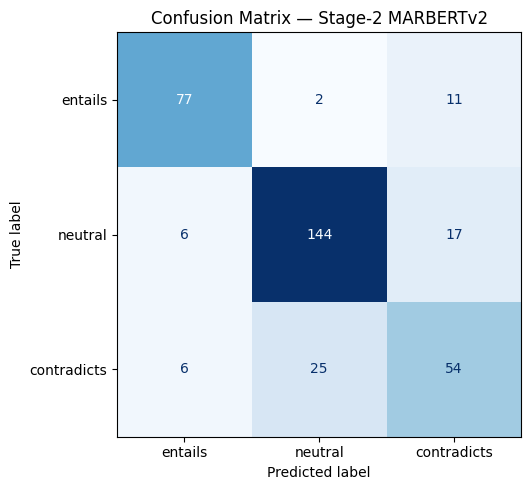

Saved → confusion_matrix.png


In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Load model and tokenizer ---
MODEL_PATH = "models/stage2_domain"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_PATH)
model      = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=3)
model.eval()
if torch.cuda.is_available():
    model = model.cuda()

# --- Load and split data (same split as training) ---
df = pd.read_csv("final_balanced_dataset.csv")
df = df.dropna(subset=["claim", "evidence", "nli_label"])
df["label_int"] = df["nli_label"].astype(int)
labels = df["label_int"].tolist()

_, val_claims, _, val_evidences, _, true_labels = train_test_split(
    df["claim"].tolist(),
    df["evidence"].tolist(),
    labels,
    test_size=0.1,
    random_state=42,
    stratify=labels,
)

# --- Run inference on validation set ---
predictions = []
batch_size  = 16

for i in range(0, len(val_claims), batch_size):
    batch_claims    = val_claims[i:i+batch_size]
    batch_evidences = val_evidences[i:i+batch_size]

    inputs = tokenizer(
        batch_claims, batch_evidences,
        truncation=True, padding=True,
        max_length=512, return_tensors="pt"
    )
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    predictions.extend(preds)

# --- Classification report ---
print(classification_report(
    true_labels, predictions,
    target_names=["entails", "neutral", "contradicts"]
))

# --- Confusion matrix ---
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["entails", "neutral", "contradicts"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Stage-2 MARBERTv2")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved → confusion_matrix.png")

in the code below we used to compare VS  a baseline model of always predicting the Major class in our case its neutral 

In [2]:
from sklearn.metrics import classification_report

# Always predict neutral (class 1) — most frequent class
majority_preds = [1] * len(true_labels)

print("=== Majority Class Baseline ===")
print(classification_report(
    true_labels, majority_preds,
    target_names=["entails", "neutral", "contradicts"]
))

=== Majority Class Baseline ===
              precision    recall  f1-score   support

     entails       0.00      0.00      0.00        90
     neutral       0.49      1.00      0.66       167
 contradicts       0.00      0.00      0.00        85

    accuracy                           0.49       342
   macro avg       0.16      0.33      0.22       342
weighted avg       0.24      0.49      0.32       342



c:\Users\USER\Desktop\py\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Desktop\py\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Desktop\py\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


in the code below we fine-tuned ARABERT  on our dataset for the sake of comparisens 


In [3]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

ARABERT_MODEL = "aubmindlab/bert-base-arabertv2"
DATASET_PATH  = "final_balanced_dataset.csv"
SAVE_DIR      = "models/arabert_baseline"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Dataset class ---
class NLIDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# --- Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }

# --- Load data ---
df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=["claim", "evidence", "nli_label"])
df["label_int"] = df["nli_label"].astype(int)
labels = df["label_int"].tolist()

(train_claims, val_claims,
 train_evidences, val_evidences,
 train_labels, val_labels) = train_test_split(
    df["claim"].tolist(),
    df["evidence"].tolist(),
    labels,
    test_size=0.1,
    random_state=42,   # same seed as MARBERTv2 — identical val split
    stratify=labels,
)

# --- Tokenize ---
print("Loading AraBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(ARABERT_MODEL)

train_enc = tokenizer(train_claims, train_evidences,
                      truncation=True, padding=True, max_length=512)
val_enc   = tokenizer(val_claims,   val_evidences,
                      truncation=True, padding=True, max_length=512)

train_ds = NLIDataset(train_enc, train_labels)
val_ds   = NLIDataset(val_enc,   val_labels)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

# --- Train ---
print("Training AraBERT baseline...")
model = AutoModelForSequenceClassification.from_pretrained(
    ARABERT_MODEL, num_labels=3
)

training_args = TrainingArguments(
    output_dir                  = "./results/arabert",
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = "cosine",
    label_smoothing_factor      = 0.05,
    bf16                        = torch.cuda.is_available(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 10,
    save_total_limit            = 1,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

# --- Evaluate ---
print("\n=== AraBERT Baseline Results ===")
predictions = []
model.eval()
for i in range(0, len(val_claims), 16):
    inputs = tokenizer(
        val_claims[i:i+16], val_evidences[i:i+16],
        truncation=True, padding=True,
        max_length=512, return_tensors="pt"
    )
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    predictions.extend(torch.argmax(logits, dim=-1).cpu().numpy())

print(classification_report(
    val_labels, predictions,
    target_names=["entails", "neutral", "contradicts"]
))

trainer.save_model(SAVE_DIR)
print(f"Model saved → {SAVE_DIR}")


Loading AraBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

c:\Users\USER\Desktop\py\myenv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--aubmindlab--bert-base-arabertv2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.776100,0.800494,0.678363,0.614664
2,0.790300,0.650393,0.760234,0.717773
3,0.453300,0.658839,0.763158,0.741553
4,0.337600,0.673243,0.807018,0.793457
5,0.302000,0.760394,0.795322,0.783585
6,0.204800,0.736379,0.809942,0.799769
7,0.190600,0.738356,0.824561,0.813050
8,0.199800,0.765562,0.812865,0.802226
9,0.176600,0.768569,0.818713,0.809000
10,0.171800,0.771806,0.818713,0.809000



=== AraBERT Baseline Results ===
              precision    recall  f1-score   support

     entails       0.89      0.89      0.89        90
     neutral       0.87      0.85      0.86       167
 contradicts       0.67      0.71      0.69        85

    accuracy                           0.82       342
   macro avg       0.81      0.82      0.81       342
weighted avg       0.83      0.82      0.83       342

Model saved → models/arabert_baseline
